In [77]:
import pandas as pd
import warnings
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

In [78]:
import pandas as pd

file_path = "merged_brfss_aqi_2023.csv" 
df = pd.read_csv(file_path)

df.head(5)

,State,_URBSTAT,SEXVAR,_SEX,_AGEG5YR,EDUCA,INCOME3,RENTHOM1,EMPLOY1,_STSTR,...,ECIGNOW2,EXERANY2,AVEDRNK3,PRIMINS1,MEDCOST1,CHECKUP1,PERSDOC3,Year,Ozone_8-HR RUN AVG BEGIN HOUR_Ozone 8-hour 2015,PM2.5 - Local Conditions_24-HR BLK AVG_PM25 24-hour 2024
0,Alabama,1.0,Female,Male,Age 25 to 29,5.0,99.0,1.0,7.0,11011,...,1.0,2.0,NaN,3.0,2.0,2.0,1.0,2023,0.043164,8.369426
1,Alabama,1.0,Female,Male,Age 25 to 29,5.0,99.0,1.0,7.0,11012,...,1.0,1.0,NaN,3.0,2.0,2.0,1.0,2023,0.043164,8.369426
2,Alabama,1.0,Female,Male,Age 25 to 29,4.0,2.0,2.0,7.0,11011,...,1.0,1.0,NaN,3.0,1.0,1.0,1.0,2023,0.043164,8.369426
3,Alabama,1.0,Female,Male,Age 25 to 29,5.0,99.0,1.0,7.0,11011,...,1.0,1.0,NaN,3.0,2.0,3.0,1.0,2023,0.043164,8.369426
4,Alabama,1.0,Female,Male,Age 25 to 29,5.0,7.0,1.0,8.0,11011,...,1.0,1.0,88.0,3.0,2.0,1.0,1.0,2023,0.043164,8.369426


It would be interesting to see if there is a difference in pollution levels in different areas. In this case, we will be looking at the difference in Ozone and PM2.5 levels in urban vs. rural areas. We have created a bar chart below to best compare the two:

We would hypothesize that urban areas would have higher levels of pollution over all, but that doesn't seem to be the case. We can see from the charts that urban and rural areas have just about the same Ozone levels. The PM2.5 levels are sightly higher in urban areas, and this could be due to the fact that there is alot more pollutants such as vehicle traffic and factories that could contribute to the PM2.5 levels.

We also wonder if there's a correlation between different kinds of respiratory issues and different kinds of pollutants. In this case we want to see if there's a correlation between respiratory issues Asthma and COPDwith ozone and PM2.5. We can create a heatmap to do this.

In [88]:
#shorten ozone and pm2.5 names
df = df.rename(columns={
    'Ozone_8-HR RUN AVG BEGIN HOUR_Ozone 8-hour 2015': 'Ozone',
    'PM2.5 - Local Conditions_24-HR BLK AVG_PM25 24-hour 2024': 'PM2.5'
})

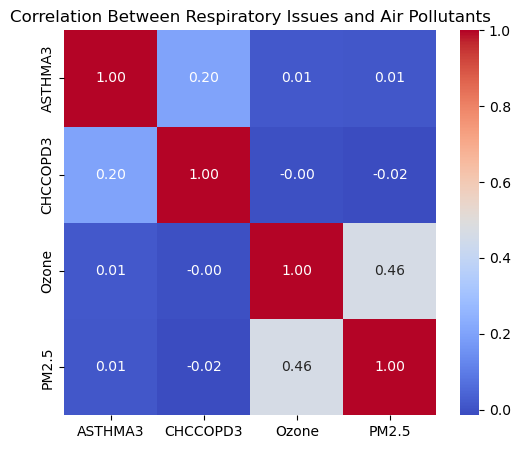

In [89]:
corr_df = df[['ASTHMA3', 'CHCCOPD3', 'Ozone', 'PM2.5']].copy()
corr_df = corr_df.dropna()
#correlation matrix
corr_matrix = corr_df.corr()

# plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Respiratory Issues and Air Pollutants")
plt.show()

Surprisingly enough, it looks like there really isnt any correlation between respiratory issues and pollutants like Ozone and PM2.5. But it does seem like there is a weak postive correlation between Asthma and COPD as well as a positive correlation between Ozone and PM2.5. This is expected as they are both in the same category and are often present simultaneously. 

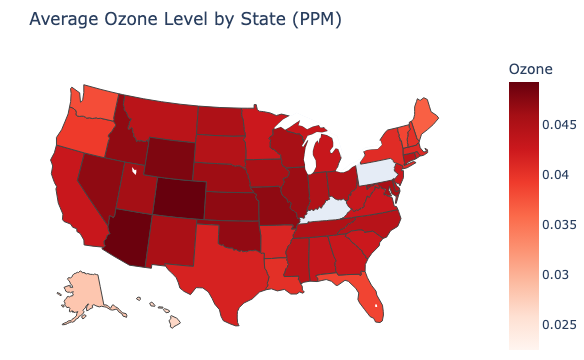

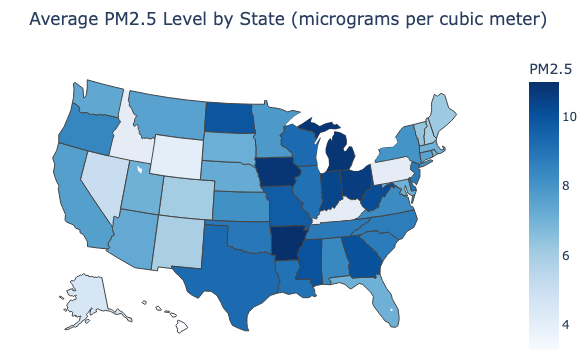

In [93]:
# We needed to manually add the state codes to display the results
state_codes = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
    'Colorado':'CO','Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA',
    'Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA',
    'Kansas':'KS','Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD',
    'Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
    'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV','New Hampshire':'NH',
    'New Jersey':'NJ','New Mexico':'NM','New York':'NY','North Carolina':'NC',
    'North Dakota':'ND','Ohio':'OH','Oklahoma':'OK','Oregon':'OR','Pennsylvania':'PA',
    'Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD','Tennessee':'TN',
    'Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA','Washington':'WA',
    'West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY'
}
state_avg["StateCode"] = state_avg["State"].map(state_codes)
# Plot Choropleth Map,axis,title,and colors
def plot_choropleth(metric, title, colorscale):
    fig = px.choropleth(
        state_avg,
        locations="StateCode",
        locationmode="USA-states",
        color=metric,
        scope="usa",
        color_continuous_scale=colorscale,
        title=title
    )
    # adjusting the margins and title
    fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
    fig.show()

# Plotting Ozone and PM2.5 Maps
plot_choropleth("Ozone", "Average Ozone Level by State (PPM)", "Reds")
plot_choropleth("PM2.5", "Average PM2.5 Level by State (micrograms per cubic meter)", "Blues")